wobbleflow notebook

# Setup

In [17]:
# Import Libraries
from __future__ import annotations
import math
from typing import Callable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

Get Radial velocity measurements of the K2-24 system (EPIC 203771098), which is a CSV file from the RadVel package GitHub repository. The dataset contains 32 observations of time, radial velocity, and measurement error, and is the same dataset used in the official tutorials for the RadVel and exoplanet packages. The radial velocity measurements were collected with Keck/HIRES by the California Planet Search team and published in Petigura et al. (2016, 2018). The CSV file in the RadVel repository is the cleaned, redistributable form of that published data, and the K2-24 system is catalogued in the NASA Exoplanet Archive.

In [14]:
df = pd.read_csv('https://raw.githubusercontent.com/California-Planet-Search/radvel/master/example_data/epic203771098.csv')
df = df.drop(columns=['Unnamed: 0'])

In [18]:
df.shape # To confirm there is, in fact, 32 observations

(32, 3)

In [21]:
df.head(6) # The table has measurement error (errvel), time (t), and radial velocity (vel)

,errvel,t,vel
0,1.593725,2364.819580,6.959066
1,1.600745,2364.825101,5.017650
2,1.658815,2364.830703,13.811799
3,1.653224,2366.827579,1.151030
4,1.639095,2367.852646,9.389273
5,1.723691,2373.888150,-2.820614


Text(0, 0.5, 'radial velocity [m/s]')

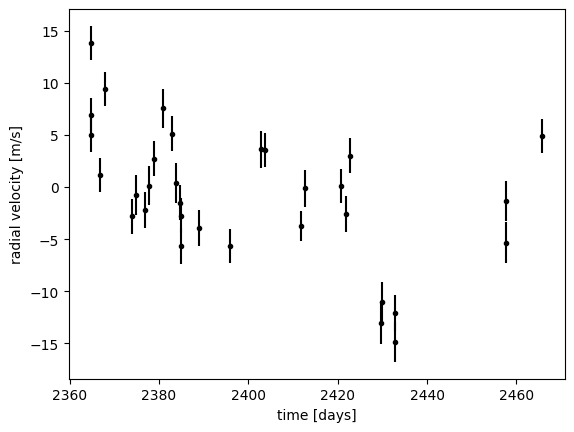

In [16]:
plt.errorbar(df.t, df.vel, yerr=df.errvel, fmt='.k')
plt.xlabel('time [days]')
plt.ylabel('radial velocity [m/s]')

# Model Setup

## Keplerian Orbit Model

In [ ]:
def solve_kepler_equation(M: Tensor, e: Tensor,
                          n_iter: int = 50,
                          tol: float = 1e-10) -> Tensor:
    """Solve M = E - e sin(E) for E by Newton's method.
    The starting guess E0 = M is good enough for the moderate eccentricities
    encountered in RV fits (e < ~0.9). Wrapping M to [-pi, pi] keeps the
    Newton iterates from drifting across multiple orbital cycles.

    Parameters
    ----------
    M : Tensor
        Mean anomaly (radians). Any shape.
    e : Tensor
        Eccentricity, in [0, 1). Broadcastable against M.
    n_iter : int
        Maximum number of Newton iterations. We exit early if the residual
        falls below `tol`.
    tol : float
        Convergence tolerance on |E - e sin(E) - M|.

    Returns
    -------
    Tensor with the same shape as M, holding the eccentric anomaly E.
    """
    M = torch.remainder(M + math.pi, 2 * math.pi) - math.pi
    E = M.clone()
    for _ in range(n_iter):
        f = E - e * torch.sin(E) - M
        fp = 1.0 - e * torch.cos(E)
        E = E - f / fp
        if torch.max(torch.abs(f)) < tol:
            break
    return E


def true_anomaly(M: Tensor, e: Tensor) -> Tensor:
    """Convert mean anomaly M to true anomaly nu given eccentricity e.
    Uses the standard half-angle identity
        tan(nu / 2) = sqrt((1 + e) / (1 - e)) * tan(E / 2)
    rewritten in atan2 form, which gives the correct quadrant of nu without
    the periodic discontinuities of arctan."""
    E = solve_kepler_equation(M, e)
    sin_half = torch.sqrt(1.0 + e) * torch.sin(E / 2.0)
    cos_half = torch.sqrt(1.0 - e) * torch.cos(E / 2.0)
    return 2.0 * torch.atan2(sin_half, cos_half)


def rv_one_planet(t: Tensor,
                  P: Tensor, tp: Tensor, e: Tensor,
                  omega: Tensor, K: Tensor) -> Tensor:
    """Predicted RV contribution from a single planet at observation times t.
    Implements
        v_r(t) = K [cos(omega + nu(t)) + e cos(omega)]
    with M(t) = 2 pi (t - tp) / P. All inputs are broadcastable Tensors.
    """
    M = 2.0 * math.pi * (t - tp) / P
    nu = true_anomaly(M, e)
    return K * (torch.cos(omega + nu) + e * torch.cos(omega))


def rv_model_two_planet(t: Tensor, theta: Tensor) -> Tensor:
    """Predicted RV from a two-planet Keplerian model at observation times t.
    The parameter vector is laid out as
        theta = [P1, tp1, e1, omega1, K1, P2, tp2, e2, omega2, K2, v0]
    with units (days, days, unitless, radians, m/s, ..., m/s).
    Note, the jitter parameter is handled separately in the likelihood, not here."""
    P1, tp1, e1, w1, K1 = theta[0], theta[1], theta[2], theta[3], theta[4]
    P2, tp2, e2, w2, K2 = theta[5], theta[6], theta[7], theta[8], theta[9]
    v0 = theta[10]
    rv1 = rv_one_planet(t, P1, tp1, e1, w1, K1)
    rv2 = rv_one_planet(t, P2, tp2, e2, w2, K2)
    return v0 + rv1 + rv2


def log_likelihood_two_planet(theta: Tensor,
                              t: Tensor,
                              rv_obs: Tensor,
                              rv_err: Tensor,
                              log_jitter: Tensor) -> Tensor:
    """Gaussian log-likelihood with an additive jitter term.
    The noise model is
        rv_obs[i] ~ Normal(rv_pred(t[i]; theta), rv_err[i]^2 + jitter^2),
    where jitter is a scalar added in quadrature to absorb stellar activity
    and instrumental systematics not captured by the reported error bars.
    Working in log-space for the jitter (log_jitter) keeps it strictly
    positive without needing a constrained optimizer."""
    rv_pred = rv_model_two_planet(t, theta)
    sigma2 = rv_err ** 2 + torch.exp(2.0 * log_jitter)
    resid = rv_obs - rv_pred
    return -0.5 * torch.sum(resid ** 2 / sigma2 + torch.log(2.0 * math.pi * sigma2))

## Priors & Log Posterior

In [ ]:
# Period prior: log-uniform on [P_MIN, P_MAX] days. The bounds bracket the
# K2-24 system (transit-derived periods ~21 and ~42 days) by ~2 orders of
# magnitude on each side, which leaves room for the multimodal alias
# structure to manifest in the posterior.
P_MIN, P_MAX = 1.0, 1000.0

# Time-of-periastron prior: uniform on [TP_MIN, TP_MAX]. Set wider than the
# data window so the prior never truncates the posterior.
TP_MIN, TP_MAX = 2300.0, 2500.0

# Eccentricity prior: Beta(KIPPING_A, KIPPING_B). Mildly favors low e, which
# matches what we know empirically about long-period exoplanets.
KIPPING_A, KIPPING_B = 0.867, 3.03

# Semi-amplitude prior: half-normal with scale K_SCALE. K2-24's RV swing is
# about 10 m/s, so a scale of 50 is generous and weakly informative.
K_SCALE = 50.0

# Systemic velocity prior: zero-mean Gaussian. The data is mean-subtracted in
# practice so v0 should be near zero, but we keep a wide prior.
V0_SCALE = 50.0

# Log-jitter prior: uniform on [LOG_JIT_MIN, LOG_JIT_MAX]. This corresponds
# to jitter values in roughly [exp(-5), exp(3)] = [0.007, 20] m/s.
LOG_JIT_MIN, LOG_JIT_MAX = -5.0, 3.0


def _log_uniform_period(P: Tensor) -> Tensor:
    """Log of the log-uniform prior on period, restricted to [P_MIN, P_MAX].
    p(P) ~ 1/P on the support, so log p(P) = -log P - log log(P_MAX/P_MIN)."""
    in_range = (P >= P_MIN) & (P <= P_MAX)
    log_norm = math.log(math.log(P_MAX / P_MIN))
    val = -torch.log(P) - log_norm
    return torch.where(in_range, val, torch.full_like(P, float("-inf")))


def _log_uniform(x: Tensor, low: float, high: float) -> Tensor:
    """Log of a uniform density on [low, high]; -inf outside."""
    in_range = (x >= low) & (x <= high)
    log_norm = math.log(high - low)
    return torch.where(in_range,
                       torch.full_like(x, -log_norm),
                       torch.full_like(x, float("-inf")))


def _log_beta(x: Tensor, a: float, b: float) -> Tensor:
    """Log of the Beta(a, b) density on (0, 1).
    The clamps below are defensive and only ever activate at the open
    boundary, where the density is anyway -inf or +inf. They keep autograd
    from producing NaNs from log(0)."""
    in_range = (x > 0) & (x < 1)
    log_norm = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    val = ((a - 1.0) * torch.log(x.clamp(min=1e-30))
           + (b - 1.0) * torch.log1p(-x.clamp(max=1.0 - 1e-12))
           - log_norm)
    return torch.where(in_range, val, torch.full_like(x, float("-inf")))


def _log_half_normal(x: Tensor, scale: float) -> Tensor:
    """Log of a half-normal density on x >= 0 with the given scale."""
    in_range = x >= 0
    log_norm = 0.5 * math.log(2.0 / math.pi) - math.log(scale)
    val = log_norm - 0.5 * (x / scale) ** 2
    return torch.where(in_range, val, torch.full_like(x, float("-inf")))


def _log_normal(x: Tensor, mean: float, scale: float) -> Tensor:
    """Log of a Normal(mean, scale^2) density."""
    return (-0.5 * ((x - mean) / scale) ** 2
            - math.log(scale)
            - 0.5 * math.log(2.0 * math.pi))


def log_prior_two_planet(theta: Tensor, log_jitter: Tensor) -> Tensor:
    """Sum of independent log-priors over each orbital parameter.

    Parameters
    ----------
    theta : Tensor of shape (11,)
        [P1, tp1, e1, omega1, K1, P2, tp2, e2, omega2, K2, v0].
    log_jitter : Tensor (scalar)
        Log of the jitter standard deviation in m/s.

    Returns
    -------
    Scalar Tensor: sum of log priors. -inf if any parameter is outside its
    support.
    """
    P1, tp1, e1, w1, K1 = theta[0], theta[1], theta[2], theta[3], theta[4]
    P2, tp2, e2, w2, K2 = theta[5], theta[6], theta[7], theta[8], theta[9]
    v0 = theta[10]

    return (
        _log_uniform_period(P1)
        + _log_uniform(tp1, TP_MIN, TP_MAX)
        + _log_beta(e1, KIPPING_A, KIPPING_B)
        + _log_uniform(w1, 0.0, 2.0 * math.pi)
        + _log_half_normal(K1, K_SCALE)
        + _log_uniform_period(P2)
        + _log_uniform(tp2, TP_MIN, TP_MAX)
        + _log_beta(e2, KIPPING_A, KIPPING_B)
        + _log_uniform(w2, 0.0, 2.0 * math.pi)
        + _log_half_normal(K2, K_SCALE)
        + _log_normal(v0, 0.0, V0_SCALE)
        + _log_uniform(log_jitter, LOG_JIT_MIN, LOG_JIT_MAX)
    )


def log_posterior_two_planet(theta: Tensor,
                             log_jitter: Tensor,
                             t: Tensor,
                             rv_obs: Tensor,
                             rv_err: Tensor) -> Tensor:
    """Unnormalized log posterior in the natural (constrained) parameter space.
    log pi(theta, log_jitter | data) = log L + log prior, up to an additive constant."""
    return (
        log_likelihood_two_planet(theta, t, rv_obs, rv_err, log_jitter)
        + log_prior_two_planet(theta, log_jitter)
    )

## Unconstrained Reparameterization

In [ ]:
def eta_to_theta(eta: Tensor):
    """Map eta in R^12 to (theta in R^11, log_jitter scalar).

    Returns the constrained-space parameter vector and the scalar log-jitter,
    so downstream code (likelihoods, priors) can use them directly.
    """
    P1 = torch.exp(eta[0])
    tp1 = eta[1]
    e1 = torch.sigmoid(eta[2])
    w1 = eta[3]
    K1 = torch.exp(eta[4])
    P2 = torch.exp(eta[5])
    tp2 = eta[6]
    e2 = torch.sigmoid(eta[7])
    w2 = eta[8]
    K2 = torch.exp(eta[9])
    v0 = eta[10]
    log_jitter = eta[11]
    theta = torch.stack([P1, tp1, e1, w1, K1, P2, tp2, e2, w2, K2, v0])
    return theta, log_jitter


def log_jacobian(eta: Tensor) -> Tensor:
    """Sum of per-coordinate log-Jacobian contributions for eta -> theta."""
    # Two log-period contributions: log P = eta itself.
    j = eta[0] + eta[5]
    # Two log-K contributions, same pattern.
    j = j + eta[4] + eta[9]
    # Two logit-eccentricity contributions: log(e (1 - e)).
    e1 = torch.sigmoid(eta[2])
    e2 = torch.sigmoid(eta[7])
    j = j + torch.log(e1) + torch.log1p(-e1) + torch.log(e2) + torch.log1p(-e2)
    return j


def log_posterior_unconstrained(eta: Tensor,
                                t: Tensor,
                                rv_obs: Tensor,
                                rv_err: Tensor) -> Tensor:
    """Log posterior in eta-space, including the log-Jacobian correction."""
    theta, log_jitter = eta_to_theta(eta)
    return (log_posterior_two_planet(theta, log_jitter, t, rv_obs, rv_err)
            + log_jacobian(eta))


def eta_samples_to_theta(eta_samples: Tensor) -> Tensor:
    """Vectorized eta -> theta mapping for batches of samples.
    Inputs a (n, 12) tensor of eta samples, returns a (n, 12) tensor whose
    last column is log_jitter (kept on the log scale, since that's what the
    likelihood uses)."""
    P1 = torch.exp(eta_samples[:, 0])
    tp1 = eta_samples[:, 1]
    e1 = torch.sigmoid(eta_samples[:, 2])
    w1 = eta_samples[:, 3]
    K1 = torch.exp(eta_samples[:, 4])
    P2 = torch.exp(eta_samples[:, 5])
    tp2 = eta_samples[:, 6]
    e2 = torch.sigmoid(eta_samples[:, 7])
    w2 = eta_samples[:, 8]
    K2 = torch.exp(eta_samples[:, 9])
    v0 = eta_samples[:, 10]
    lj = eta_samples[:, 11]
    return torch.stack([P1, tp1, e1, w1, K1, P2, tp2, e2, w2, K2, v0, lj], dim=1)


def initial_eta() -> Tensor:
    """A reasonable starting point for chains and VI initializations.
    Uses the K2-24 transit-derived periods (~20.89 and ~42.36 days) and weak
    guesses elsewhere. This puts the initial state in a region of high
    posterior density without injecting too much information.
    """
    return torch.tensor([
        math.log(20.89),         # log P1
        2380.0,                  # tp1, inside the data window
        math.log(0.05 / 0.95),   # logit e1, e ~ 0.05
        0.0,                     # omega1
        math.log(8.0),           # log K1, K ~ 8 m/s
        math.log(42.36),         # log P2
        2400.0,                  # tp2
        math.log(0.05 / 0.95),   # logit e2
        0.0,                     # omega2
        math.log(6.0),           # log K2
        0.0,                     # v0
        0.0,                     # log_jitter, jitter ~ 1 m/s
    ])

## Flows

### Planar Flow

In [ ]:
# Planar normalizing flow (Rezende and Mohamed 2015)

class PlanarLayer(nn.Module):
    """A single planar transformation f(z) = z + u h(w^T z + b)."""

    def __init__(self, D: int):
        super().__init__()
        # Small init: starts essentially as the identity map.
        self.u = nn.Parameter(torch.randn(D) * 0.01)
        self.w = nn.Parameter(torch.randn(D) * 0.01)
        self.b = nn.Parameter(torch.zeros(1))

    def u_hat(self) -> torch.Tensor:
        """Reparameterized u that enforces w^T u_hat >= -1."""
        wu = torch.dot(self.w, self.u)
        m_wu = -1.0 + F.softplus(wu)  # m(x) = -1 + log(1 + exp x)
        return self.u + (m_wu - wu) * self.w / (torch.dot(self.w, self.w) + 1e-12)

    def forward(self, z: torch.Tensor):
        """Apply the planar map and return (f(z), log|det df/dz|).
        z is shape (n, D); the returned tensors are (n, D) and (n,).
        """
        u_hat = self.u_hat()
        a = z @ self.w + self.b                          # (n,)
        f_z = z + u_hat.unsqueeze(0) * torch.tanh(a).unsqueeze(1)
        psi = (1.0 - torch.tanh(a) ** 2).unsqueeze(1) * self.w.unsqueeze(0)  # (n, D)
        log_det = torch.log(torch.abs(1.0 + psi @ u_hat) + 1e-12)            # (n,)
        return f_z, log_det

### Real-NVP

In [ ]:
# Real-NVP coupling-layer flow (Dinh, Sohl-Dickstein & Bengio 2017)

class CouplingLayer(nn.Module):
    """One Real-NVP coupling layer with a fixed binary mask."""

    def __init__(self, D: int, mask: torch.Tensor, hidden: int = 64):
        super().__init__()
        self.register_buffer("mask", mask)
        # Two MLPs sharing architecture but distinct weights.
        # The final tanh on s_net keeps |s| bounded, which improves stability
        # in early training (a trick used in flonaco and many follow-ups).
        self.s_net = nn.Sequential(
            nn.Linear(D, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, D), nn.Tanh(),
        )
        self.t_net = nn.Sequential(
            nn.Linear(D, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, D),
        )

        # Init the last layer of each net to zero so the layer starts as the
        # identity map. This makes early training much more stable.
        for m in (self.s_net[-1], self.t_net[-1]):
            nn.init.zeros_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor):
        """z -> y. Returns (y, log|det df/dz|)."""
        z_masked = z * self.mask
        s = self.s_net(z_masked) * (1 - self.mask)
        t = self.t_net(z_masked) * (1 - self.mask)
        y = z_masked + (1 - self.mask) * (z * torch.exp(s) + t)
        log_det = s.sum(dim=-1)
        return y, log_det

    def inverse(self, y: torch.Tensor):
        """y -> z. Returns (z, log|det dg/dy|), where g = f^{-1}."""
        y_masked = y * self.mask
        s = self.s_net(y_masked) * (1 - self.mask)
        t = self.t_net(y_masked) * (1 - self.mask)
        z = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-s))
        log_det = -s.sum(dim=-1)
        return z, log_det


class RealNVP(nn.Module):
    """Stack of Real-NVP coupling layers with alternating stripe masks."""

    def __init__(self, D: int, n_layers: int = 6, hidden: int = 64):
        super().__init__()
        self.D = D
        self.layers = nn.ModuleList()
        for k in range(n_layers):
            mask = torch.zeros(D)
            mask[k % 2 :: 2] = 1.0          # alternating stripes
            self.layers.append(CouplingLayer(D, mask, hidden=hidden))

    def forward(self, z: torch.Tensor):
        """Push base samples z through the flow. Returns (y, sum log|det|)."""
        log_det = torch.zeros(z.shape[0])
        for layer in self.layers:
            z, ld = layer(z)
            log_det = log_det + ld
        return z, log_det

    def inverse(self, y: torch.Tensor):
        """Pull y back to base samples z. Returns (z, sum log|det|)."""
        log_det = torch.zeros(y.shape[0])
        for layer in reversed(self.layers):
            y, ld = layer.inverse(y)
            log_det = log_det + ld
        return y, log_det

    def log_q(self, y: torch.Tensor) -> torch.Tensor:
        """log of the pushforward density at y, i.e. log rho_hat(y).
        Uses the change of variables: if z = T^{-1}(y) and rho_B is the base
        density (standard normal here), then
            rho_hat(y) = rho_B(z) |det dT^{-1}/dy|.
        """
        z, log_det_inv = self.inverse(y)
        log_base = (-0.5 * z ** 2 - 0.5 * math.log(2.0 * math.pi)).sum(dim=-1)
        return log_base + log_det_inv

    def sample(self, n: int):
        """Draw n samples from the pushforward distribution.
        Returns (y, log_q(y)) so callers don't need a separate log_q call.
        """
        z = torch.randn(n, self.D)
        y, log_det = self.forward(z)
        log_base = (-0.5 * z ** 2 - 0.5 * math.log(2.0 * math.pi)).sum(dim=-1)
        log_q = log_base - log_det
        return y, log_q

## Inference

### Hamiltonian Monte Carlo

In [ ]:
# Hamiltonian Monte Carlo with leapfrog integration

def potential_and_grad(eta: Tensor,
                       log_post_fn: Callable[[Tensor], Tensor]
                       ):
    """Compute U(eta) = -log pi(eta) and grad U(eta).
    We use PyTorch autograd, which means `log_post_fn` must be a
    differentiable function of eta. Detaching at the end keeps the returned
    tensors out of the autograd graph.
    """
    eta = eta.detach().clone().requires_grad_(True)
    U = -log_post_fn(eta)
    grad = torch.autograd.grad(U, eta)[0]
    return U.detach(), grad.detach()


def hmc_step(eta_current: Tensor,
             log_post_fn: Callable[[Tensor], Tensor],
             epsilon: float,
             L: int):
    """One HMC transition: sample momentum, leapfrog, MH-correct.

    Parameters
    ----------
    eta_current : current state of the chain.
    log_post_fn : differentiable log-posterior in eta-space.
    epsilon : leapfrog step size.
    L : number of leapfrog steps per transition.

    Returns
    -------
    eta_new : the new state (either the proposal or the current state).
    accepted : whether the proposal was accepted.
    U_value : potential energy at the returned state, useful for diagnostics.
    """
    eta = eta_current.detach().clone()
    v = torch.randn_like(eta)

    U_curr, grad_curr = potential_and_grad(eta, log_post_fn)
    K_curr = 0.5 * torch.sum(v ** 2)

    # Leapfrog: half-step v, then alternating full-step eta and full-step v,
    # ending with a final half-step v. This is the symmetric form in lecture
    # 34, eq. 12; the symmetry is what makes the discretization reversible.
    eta_new = eta.clone()
    v_new = v - 0.5 * epsilon * grad_curr
    grad_new = grad_curr.clone()
    for j in range(L):
        eta_new = eta_new + epsilon * v_new
        U_new, grad_new = potential_and_grad(eta_new, log_post_fn)
        if j != L - 1:
            v_new = v_new - epsilon * grad_new
    v_new = v_new - 0.5 * epsilon * grad_new

    # Negate momentum for involutivity. The sign flip doesn't change the
    # acceptance probability (since v ~ N(0, I) is symmetric), but it makes
    # the proposal map an involution, which is the standard derivation
    # (Neal 2011; lecture 34 eq. 7).
    v_new = -v_new

    K_new = 0.5 * torch.sum(v_new ** 2)
    log_alpha = U_curr + K_curr - U_new - K_new

    if torch.log(torch.rand(())) < log_alpha:
        return eta_new.detach(), True, float(U_new)
    return eta_current.detach(), False, float(U_curr)


def run_hmc(eta_init: Tensor,
            log_post_fn: Callable[[Tensor], Tensor],
            n_samples: int,
            epsilon: float,
            L: int,
            burn_in: int = 0,
            verbose: bool = False):
    """Run an HMC chain for `burn_in + n_samples` iterations.
    Returns the post-burn-in samples and the post-burn-in acceptance rate.
    Tuning epsilon and L is part of the project; for our 12-dimensional
    target, epsilon ~ 1e-3 and L ~ 30 give acceptance in the 70-90% range.
    """
    eta = eta_init.detach().clone()
    samples = torch.empty((n_samples, eta.numel()))
    n_accept = 0
    total = burn_in + n_samples

    for i in range(total):
        eta, accepted, U_val = hmc_step(eta, log_post_fn, epsilon, L)
        if i >= burn_in:
            samples[i - burn_in] = eta
            n_accept += int(accepted)
        if verbose and (i + 1) % 200 == 0:
            phase = "burn-in" if i < burn_in else "sampling"
            print(f"[{phase}] iter {i+1:5d}/{total}  U = {U_val:.2f}")

    return samples, n_accept / n_samples

### Mean-Field Variational Inference

In [ ]:
# Mean-field Gaussian variational inference

def gaussian_entropy(log_s: Tensor) -> Tensor:
    """Entropy of N(mu, diag(s^2)). Independent of mu."""
    return torch.sum(log_s) + 0.5 * log_s.numel() * (1.0 + math.log(2.0 * math.pi))


def elbo_meanfield(mu: Tensor,
                   log_s: Tensor,
                   log_post_fn: Callable[[Tensor], Tensor],
                   n_mc: int = 8) -> Tensor:
    """Monte Carlo estimate of the ELBO using the reparameterization trick.
    Drawing n_mc samples per gradient step keeps gradient noise low; 8 is
    plenty for a 12-dimensional target.
    """
    s = torch.exp(log_s)
    eps = torch.randn(n_mc, mu.numel())
    eta_samples = mu.unsqueeze(0) + s.unsqueeze(0) * eps
    log_pi = torch.stack([log_post_fn(eta_samples[i]) for i in range(n_mc)])
    return log_pi.mean() + gaussian_entropy(log_s)


def fit_meanfield(eta_init: Tensor,
                  log_post_fn: Callable[[Tensor], Tensor],
                  n_iter: int = 1500,
                  lr: float = 5e-3,
                  n_mc: int = 8,
                  verbose: bool = False):
    """Optimize the ELBO with Adam.
    Returns the fitted (mu, log_s) and the ELBO history (one value per
    iteration). Initial log_s = -2 corresponds to s ~ 0.14, which is a
    reasonable default for our reparameterized eta coordinates.
    """
    mu = eta_init.detach().clone().requires_grad_(True)
    log_s = torch.full_like(eta_init, -2.0).requires_grad_(True)

    opt = torch.optim.Adam([mu, log_s], lr=lr)
    history: List[float] = []
    for it in range(n_iter):
        opt.zero_grad()
        loss = -elbo_meanfield(mu, log_s, log_post_fn, n_mc=n_mc)
        loss.backward()
        opt.step()
        history.append(-float(loss))
        if verbose and (it + 1) % 200 == 0:
            print(f"iter {it+1:5d}  ELBO = {-float(loss):.2f}")

    return mu.detach(), log_s.detach(), history


def sample_meanfield(mu: Tensor, log_s: Tensor, n: int) -> Tensor:
    """Draw n samples from the fitted variational distribution."""
    s = torch.exp(log_s)
    eps = torch.randn(n, mu.numel())
    return mu.unsqueeze(0) + s.unsqueeze(0) * eps

### Flow-Based Variational Inference

In [ ]:
# Variational inference with planar normalizing flows

class FlowVI(nn.Module):
    """Mean-field Gaussian base + K planar transformations."""

    def __init__(self, D: int, K: int, mu_init: Tensor | None = None):
        super().__init__()
        if mu_init is None:
            mu_init = torch.zeros(D)
        self.mu = nn.Parameter(mu_init.clone())
        # log_s = -2 -> s ~ 0.14, same default as mean-field VI for fair
        # initialization across methods.
        self.log_s = nn.Parameter(torch.full((D,), -2.0))
        self.layers = nn.ModuleList([PlanarLayer(D) for _ in range(K)])

    def sample_and_log_q(self, n: int):
        """Draw n samples from q_phi and return (samples, log q at samples).
        We compute log q on the fly to avoid an expensive separate evaluation.
        log q_K = log q_0 - sum_k log|det df_k/deta_{k-1}|.
        """
        eps = torch.randn(n, self.mu.numel())
        s = torch.exp(self.log_s)
        z = self.mu.unsqueeze(0) + s.unsqueeze(0) * eps

        # log q_0(eta_0) for a diagonal Gaussian, expressed via eps so we
        # don't have to invert the reparameterization map.
        log_q = (-0.5 * eps ** 2 - self.log_s - 0.5 * math.log(2.0 * math.pi)).sum(dim=1)

        for layer in self.layers:
            z, log_det = layer(z)
            log_q = log_q - log_det
        return z, log_q


def fit_flow_vi(model: FlowVI,
                log_post_fn: Callable[[Tensor], Tensor],
                n_iter: int = 1500,
                lr: float = 5e-3,
                n_mc: int = 8,
                verbose: bool = False) -> List[float]:
    """Train a FlowVI model by maximizing the flow-based ELBO.
    Planar layers can produce large gradients early in training (the u, w
    parameters interact through u_hat in a way that occasionally amplifies
    updates). Mild gradient clipping keeps things stable; the value 5.0 is
    standard for normalizing-flow VI in practice.
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history: List[float] = []
    for it in range(n_iter):
        opt.zero_grad()
        z, log_q = model.sample_and_log_q(n_mc)
        log_pi = torch.stack([log_post_fn(z[i]) for i in range(n_mc)])
        elbo = (log_pi - log_q).mean()
        loss = -elbo
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        history.append(float(elbo))
        if verbose and (it + 1) % 200 == 0:
            print(f"iter {it+1:5d}  ELBO = {float(elbo):.2f}")
    return history

### FlowMC

In [ ]:
# Adaptive MCMC augmented with normalizing flows (Gabrié et al. 2022)

def log_post_and_grad(eta: Tensor,
                      log_post_fn: Callable[[Tensor], Tensor]):
    """log pi(eta) and its gradient (not the negative). MALA needs the grad
    of log pi, not of U; this is the cleanest place to compute it once."""
    eta = eta.detach().clone().requires_grad_(True)
    log_pi = log_post_fn(eta)
    grad = torch.autograd.grad(log_pi, eta)[0]
    return log_pi.detach(), grad.detach()


def mala_step(eta: Tensor,
              log_post_fn: Callable[[Tensor], Tensor],
              tau: float):
    """One Metropolis-adjusted Langevin step (lecture 32, eq. 2).

    Proposal:    y = x + (tau / 2) * grad log pi(x) + sqrt(tau) * eps
    Acceptance:  Metropolis-Hastings using the asymmetric proposal density.
    """
    eta = eta.detach().clone()
    log_pi_curr, grad_curr = log_post_and_grad(eta, log_post_fn)

    mu_fwd = eta + 0.5 * tau * grad_curr
    eta_prop = mu_fwd + math.sqrt(tau) * torch.randn_like(eta)

    log_pi_prop, grad_prop = log_post_and_grad(eta_prop, log_post_fn)
    mu_back = eta_prop + 0.5 * tau * grad_prop

    log_q_fwd = -0.5 * torch.sum((eta_prop - mu_fwd) ** 2) / tau
    log_q_back = -0.5 * torch.sum((eta - mu_back) ** 2) / tau

    log_alpha = (log_pi_prop - log_pi_curr) + (log_q_back - log_q_fwd)
    if torch.log(torch.rand(())) < log_alpha:
        return eta_prop.detach(), True
    return eta.detach(), False


def flow_proposal_step(eta: Tensor,
                       log_post_fn: Callable[[Tensor], Tensor],
                       flow: RealNVP):
    """One global flow-based MH step (Gabrié et al. eq. 6, 7).
    Generates an independent proposal y ~ rho_hat from the flow's
    pushforward, evaluates rho_hat at both x and y (no autograd needed,
    hence the no_grad context), and applies the MH ratio.
    """
    with torch.no_grad():
        log_pi_curr = log_post_fn(eta)
        log_q_curr = flow.log_q(eta.unsqueeze(0))[0]

        # Draw proposal from the flow's pushforward.
        z = torch.randn(1, flow.D)
        y, log_det = flow.forward(z)
        log_base = (-0.5 * z ** 2 - 0.5 * math.log(2.0 * math.pi)).sum(dim=-1)
        log_q_prop = log_base - log_det

    log_pi_prop = log_post_fn(y[0])
    log_alpha = (log_pi_prop - log_pi_curr) + (log_q_curr - log_q_prop[0])

    if torch.log(torch.rand(())) < log_alpha:
        return y[0].detach(), True
    return eta.detach(), False


def run_flowmc(eta_inits: Tensor,
               log_post_fn: Callable[[Tensor], Tensor],
               flow: RealNVP,
               n_iter: int,
               mala_tau: float,
               n_local_per_global: int,
               lr: float,
               verbose: bool = False):
    """Run Algorithm 1 of Gabrié et al. (2022) for `n_iter` outer iterations.
    `eta_inits` has shape (n_chains, D) and seeds the n_chains parallel
    walkers. Each iteration: n_local MALA steps per chain, one flow proposal
    per chain, one Adam step on the flow loss using the current chain states
    as a training batch.

    Returns the full history of chain states (shape (n_iter, n_chains, D)),
    the flow training-loss history, and the cumulative MALA / flow
    acceptance rates.
    """
    n_chains = eta_inits.shape[0]
    chains = eta_inits.detach().clone()
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)

    history: List[float] = []
    saved: List[Tensor] = []
    n_local_acc = n_local_tries = 0
    n_global_acc = n_global_tries = 0

    for step in range(n_iter):
        # Local sweeps: a few MALA steps per chain to refine within-mode mixing.
        for _ in range(n_local_per_global):
            for c in range(n_chains):
                chains[c], acc = mala_step(chains[c], log_post_fn, mala_tau)
                n_local_acc += int(acc)
                n_local_tries += 1

        # Global flow step: one independent proposal per chain.
        for c in range(n_chains):
            chains[c], acc = flow_proposal_step(chains[c], log_post_fn, flow)
            n_global_acc += int(acc)
            n_global_tries += 1

        # Train the flow on the current chain states (forward KL, eq. 11).
        # Using the live chain as the training batch is what makes this
        # method "adaptive". Gradient clipping prevents the early-training
        # explosions that Real-NVP can produce.
        optimizer.zero_grad()
        loss = -flow.log_q(chains.detach()).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        optimizer.step()

        history.append(float(loss))
        saved.append(chains.detach().clone())

        if verbose and (step + 1) % 50 == 0:
            la = n_local_acc / max(1, n_local_tries)
            ga = n_global_acc / max(1, n_global_tries)
            print(f"step {step+1:4d}  loss = {float(loss):.2f}  "
                  f"local acc = {la:.2f}  global acc = {ga:.2f}")

    samples = torch.stack(saved)
    return (samples,
            history,
            n_local_acc / max(1, n_local_tries),
            n_global_acc / max(1, n_global_tries))

# Analysis

## Diagnostics

In [ ]:
# MCMC diagnostics: autocorrelation and effective sample size

def autocorr_1d(x: np.ndarray, max_lag: Optional[int] = None) -> np.ndarray:
    """Sample autocorrelation function of a 1d array up to `max_lag`.
    Computes rho_k = (1 / (n - k)) sum_{i} (x_i - mean)(x_{i+k} - mean) / var.
    The default max_lag is N/4, which is a common practical compromise.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    if max_lag is None:
        max_lag = n // 4
    var = np.dot(x, x) / n
    rho = np.empty(max_lag)
    for k in range(max_lag):
        rho[k] = np.dot(x[: n - k], x[k:]) / ((n - k) * var)
    return rho


def ess_1d(x: np.ndarray) -> float:
    """Effective sample size of a 1d MCMC chain.
    Sums the autocorrelations up to the first negative lag, then applies
    the standard ESS formula. `max(tau, 1)` guards against pathological
    chains where the truncated sum somehow goes below 1.
    """
    rho = autocorr_1d(x, max_lag=min(len(x) // 4, 500))

    # Find the first negative lag; if every lag is nonneg, just sum all of them.
    neg_idx = np.argmax(rho < 0)
    if neg_idx == 0 and rho[0] >= 0:
        cut = len(rho)
    else:
        cut = neg_idx

    tau = 1.0 + 2.0 * np.sum(rho[1:cut])
    return len(x) / max(tau, 1.0)

In [ ]:
# Plotting helpers shared across the four inference methods

def plot_rv_with_models(t_obs: np.ndarray,
                        rv_obs: np.ndarray,
                        rv_err: np.ndarray,
                        t_dense: np.ndarray,
                        models: dict,
                        title: str = "K2-24 RV data and posterior-mean models"):
    """RV data with overlaid posterior-mean RV curves from each method.
    `models` is a dict of {method_name: rv_curve_array} where each curve has
    the same length as t_dense.
    """
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.errorbar(t_obs, rv_obs, yerr=rv_err, fmt=".k", capsize=2, label="K2-24 RV data")
    for name, curve in models.items():
        ax.plot(t_dense, curve, lw=1.2, label=f"{name} posterior mean")
    ax.set_xlabel("time [days]")
    ax.set_ylabel("radial velocity [m/s]")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()
    return fig, ax


def plot_period_posteriors(samples_dict: dict,
                           transit_truth: Tuple[float, float] = (20.89, 42.36),
                           bins_P1: Sequence[float] = None,
                           bins_P2: Sequence[float] = None):
    """Stacked histograms of P1 and P2 from each method.
    `samples_dict` is {method_name: theta_samples_array}, where the period
    columns are at indices 0 (P1) and 5 (P2).
    """
    if bins_P1 is None:
        bins_P1 = np.linspace(15, 28, 60)
    if bins_P2 is None:
        bins_P2 = np.linspace(35, 50, 60)

    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    for name, samples in samples_dict.items():
        axes[0].hist(samples[:, 0], bins=bins_P1, density=True,
                     histtype="step", lw=1.5, label=name)
        axes[1].hist(samples[:, 5], bins=bins_P2, density=True,
                     histtype="step", lw=1.5, label=name)

    axes[0].axvline(transit_truth[0], ls="--", color="k", alpha=0.5,
                    label="K2 transit value")
    axes[1].axvline(transit_truth[1], ls="--", color="k", alpha=0.5,
                    label="K2 transit value")
    axes[0].set_xlabel(r"$P_1$ [days]")
    axes[1].set_xlabel(r"$P_2$ [days]")
    for ax in axes:
        ax.set_ylabel("density")
        ax.legend(fontsize=8)
    axes[0].set_title("Posterior over orbital periods: four methods compared")
    fig.tight_layout()
    return fig, axes

In [ ]:
# ── Configuration ── #
N_HMC_SAMPLES    = 2000
N_HMC_BURN       = 500
HMC_EPS          = 2e-3
HMC_LEAPFROG     = 30
N_VI_ITER        = 1500
FLOW_LAYERS      = 8
N_FLOWMC_ITER    = 400
N_CHAINS         = 8
MALA_TAU         = 5e-5
SEED             = 0

torch.set_default_dtype(torch.float64)
torch.manual_seed(SEED)
np.random.seed(SEED)

import os
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# ── Data ── #
t_obs  = torch.tensor(df.t.values)
rv_obs = torch.tensor(df.vel.values)
rv_err = torch.tensor(df.errvel.values)

span = float(t_obs.max() - t_obs.min())
print(f"{t_obs.numel()} observations, span {span:.1f} days")

# Shared log-posterior closure targeting eta-space
def lp_eta(eta):
    return log_posterior_unconstrained(eta, t_obs, rv_obs, rv_err)

eta0 = initial_eta()

# ── Hamiltonian Monte Carlo ── # 
print("\nRunning HMC")
hmc_eta, hmc_acc = run_hmc(
    eta0, lp_eta,
    n_samples=N_HMC_SAMPLES,
    epsilon=HMC_EPS,
    L=HMC_LEAPFROG,
    burn_in=N_HMC_BURN,
    verbose=True,
)
print(f"HMC accept rate: {hmc_acc:.3f}")
hmc_theta = eta_samples_to_theta(hmc_eta)
torch.save({"samples": hmc_theta, "accept_rate": hmc_acc}, "results/hmc.pt")

# ── Mean-Field Variational Inference ── #
print("\nRunning mean-field VI")
mu_mf, log_s_mf, mf_hist = fit_meanfield(
    eta0, lp_eta, n_iter=N_VI_ITER, verbose=True,
)
mf_eta   = sample_meanfield(mu_mf, log_s_mf, n=2000)
mf_theta = eta_samples_to_theta(mf_eta)
torch.save({
    "samples": mf_theta, "mu": mu_mf, "log_s": log_s_mf, "history": mf_hist,
}, "results/vi_meanfield.pt")

# ── Flow-Based Variational Inference ── #
print("\nRunning flow VI")
fvi_model = FlowVI(D=12, K=FLOW_LAYERS, mu_init=eta0)
fvi_hist  = fit_flow_vi(fvi_model, lp_eta, n_iter=N_VI_ITER, verbose=True)
with torch.no_grad():
    fvi_eta, _ = fvi_model.sample_and_log_q(2000)
fvi_theta = eta_samples_to_theta(fvi_eta)
torch.save({
    "samples": fvi_theta,
    "model_state": fvi_model.state_dict(),
    "history": fvi_hist,
}, "results/vi_flow.pt")

# ── FlowMC ── #
print("\nRunning FlowMC")
eta_inits      = eta0.unsqueeze(0) + 0.05 * torch.randn(N_CHAINS, 12)
flow_for_mcmc  = RealNVP(D=12, n_layers=6, hidden=64)
fmc_chains, fmc_hist, fmc_local, fmc_global = run_flowmc(
    eta_inits, lp_eta, flow_for_mcmc,
    n_iter=N_FLOWMC_ITER,
    mala_tau=MALA_TAU,
    n_local_per_global=5,
    lr=5e-3,
    verbose=True,
)
burn      = N_FLOWMC_ITER // 4
fmc_pool_eta = fmc_chains[burn:].reshape(-1, 12)
fmc_theta    = eta_samples_to_theta(fmc_pool_eta)
torch.save({
    "samples":    fmc_theta,
    "chains":     fmc_chains,
    "history":    fmc_hist,
    "local_acc":  fmc_local,
    "global_acc": fmc_global,
    "flow_state": flow_for_mcmc.state_dict(),
}, "results/flowmc.pt")

# ── Diagnostics ─── #
print("\nDiagnostics:")
print(f"  HMC ESS (P1): {ess_1d(hmc_theta[:, 0].numpy()):.1f}")
print(f"  HMC ESS (P2): {ess_1d(hmc_theta[:, 5].numpy()):.1f}")

# ── Figures ── #
print("\nGenerating figures")
samples_dict = {
    "HMC":         hmc_theta.numpy(),
    "mean-field VI": mf_theta.numpy(),
    "flow VI":     fvi_theta.numpy(),
    "flow MCMC":   fmc_theta.numpy(),
}

fig, _ = plot_period_posteriors(samples_dict)
fig.savefig("figures/period_posteriors.png", dpi=150, bbox_inches="tight")
print("  Saved figures/period_posteriors.png")

t_dense = np.linspace(float(t_obs.min()), float(t_obs.max()), 500)
t_dense_t = torch.tensor(t_dense)

def posterior_mean_rv(theta_samples):
    rv_curves = torch.stack([
        rv_model_two_planet(t_dense_t, theta_samples[i, :11])
        for i in range(len(theta_samples))
    ])
    return rv_curves.mean(0).numpy()

rv_models = {name: posterior_mean_rv(torch.tensor(s)) for name, s in samples_dict.items()}
fig2, _ = plot_rv_with_models(
    t_obs.numpy(), rv_obs.numpy(), rv_err.numpy(), t_dense, rv_models,
)
fig2.savefig("figures/rv_fit.png", dpi=150, bbox_inches="tight")
print("  Saved figures/rv_fit.png")

print("\nCodeFinished.")
